In [2]:
import pandas as pd
import numpy as np

# 1. Load dataset
df = pd.read_csv(r"Downloads/marketing_campaign.csv", sep=None, engine='python')

# 2. Display basic info & check missinmg values
print("Missing Dataset:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Dataset: (2236, 32)

Missing Values:
Series([], dtype: int64)


In [6]:
# Create a copy for cleaning
df_clean = df.copy()

# 1. Handle Missing Values (Impute Income with Median)
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

# 2. Convert Dates to Datetime (handles both DD-MM-YYYY and YYYY-MM-DD)
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='mixed')

# 3. Feature Engineering: Demographics & Family
ref_year = df_clean['Dt_Customer'].dt.year.max()
df_clean['Age'] = ref_year - df_clean['Year_Birth']
df_clean['Children_Total'] = df_clean['Kidhome'] + df_clean['Teenhome']

# Simplify marital status categories
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace({
    'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'
})

# 4. Feature Engineering: Behavioral Aggregates
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['Total_Spend'] = df_clean[spend_cols].sum(axis=1)

purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_clean['Total_Purchases'] = df_clean[purchase_cols].sum(axis=1)

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
df_clean['Total_AcceptedCmp'] = df_clean[campaign_cols].sum(axis=1)

# 5. Outlier Removal (Extreme values in Age or Income)
df_clean = df_clean[(df_clean['Age'] < 90) & (df_clean['Income'] < 200000)]

# Drop redundant constant columns if any
df_clean = df_clean.drop(columns=['Z_CostContact', 'Z_Revenue'], errors='ignore')

print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (2236, 32)


In [ ]:
# Saved tge clean datase
df_clean.to_csv(r"Downloads/marketing_campaign.csv", index=False)
df_clean[['Age', 'Income', 'Total_Spend', 'Total_Purchases', 'Total_AcceptedCmp']].describe()

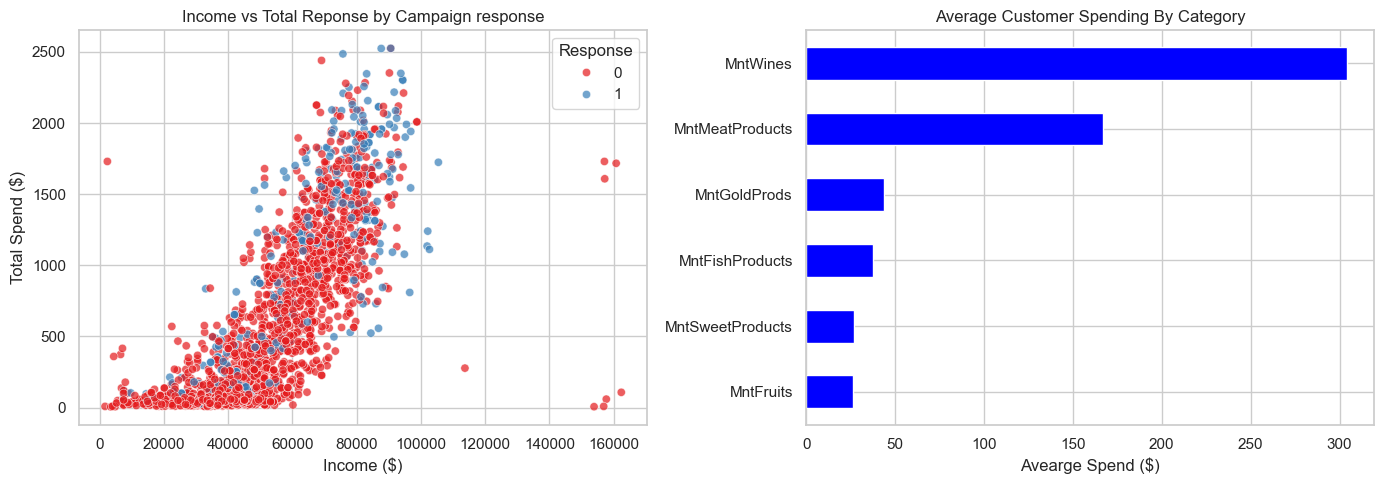

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Plot 1: Income vs. Total Spend
plt.subplot(1,2,1)
sns.scatterplot(data = df_clean, x = 'Income', y = 'Total_Spend', hue='Response', alpha=0.7, palette='Set1')
plt.title('Income vs Total Reponse by Campaign response')
plt.xlabel('Income ($)')
plt.ylabel('Total Spend ($)')

# Plot 2: Spending By Product Category
plt.subplot(1, 2, 2)
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean[spend_cols].mean().sort_values().plot(kind='barh', color='blue')
plt.title('Average Customer Spending By Category')
plt.xlabel('Avearge Spend ($)')

plt.tight_layout()
plt.show()

In [5]:
# Channel Purchases Overview
channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
channel_totals = df_clean[channels].sum()

print("=== Total Purchases by Channel ===")
print(channel_totals)

# Campaign Acceptance Rates
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
acceptance_rates = (df_clean[campaigns].mean() * 100).round(2)

print("\n=== Campaign Acceptance Rates (%) ===")
print(acceptance_rates)

=== Total Purchases by Channel ===
NumWebPurchases         9140
NumCatalogPurchases     5955
NumStorePurchases      12959
dtype: int64

=== Campaign Acceptance Rates (%) ===
AcceptedCmp1     6.44
AcceptedCmp2     1.34
AcceptedCmp3     7.29
AcceptedCmp4     7.47
AcceptedCmp5     7.25
Response        14.94
dtype: float64


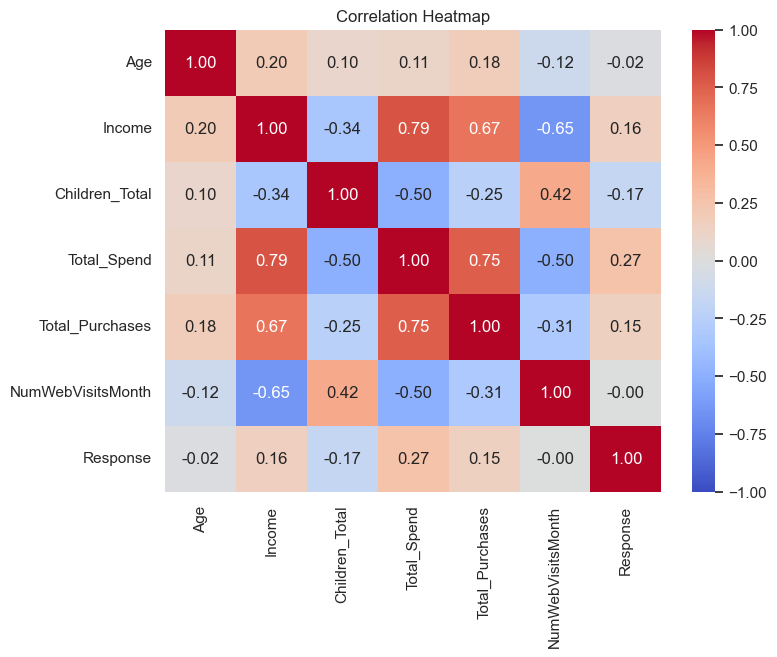

In [6]:
# Correlation of key numeric variables with campaign response
plt.figure(figsize=(8, 6))
corr_cols = ['Age', 'Income', 'Children_Total', 'Total_Spend', 'Total_Purchases', 'NumWebVisitsMonth', 'Response']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()